<a href="https://colab.research.google.com/github/chittimella-srinikitha/Data-Analytics-Projects-UM-/blob/instagram_fake_vs_genuine_proj/Instagram_fake_vs_genuine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:**
This project focuses entirely on Data Analysis (DA) of Instagram profile characteristics to understand patterns that differentiate fake accounts from genuine accounts, using a structured dataset of 785 Instagram profiles.

**Business Use:**

This analysis enables businesses and social media teams to:

* Detect suspicious or fraudulent influencer accounts

* Avoid partnering with fake accounts for promotions

* Understand behavioral patterns of real vs fake users

* Improve platform safety and authenticity

* Strengthen audience trust and reduce engagement fraud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/final-v1.csv")

print(df.info())
print(df.describe())
print(df.isnull().sum())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB
None
       edge_followed_by  edge_follow  username_length  username_has_numbe

,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
0,0.001,0.257,13,1,1,13,0,0,0,0,0,0,1
1,0.000,0.958,9,1,0,0,0,1,0,0,0,0,1
2,0.000,0.253,12,0,0,0,0,0,0,0,0,0,1
3,0.000,0.977,10,1,0,0,0,0,0,0,0,0,1
4,0.000,0.321,11,0,0,11,1,0,0,0,0,0,1


In [3]:
#Basic Data Cleaning
df['is_fake'] = df['is_fake'].astype(int)

**Exploratory Data Analysis**

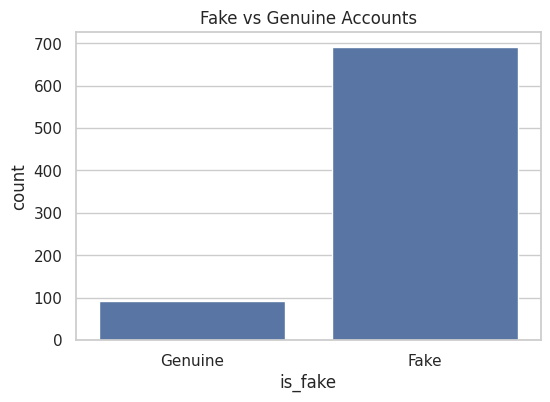

In [4]:
# Fake vs Genuine Account Count
plt.figure(figsize=(6,4))
sns.countplot(x='is_fake', data=df)
plt.title("Fake vs Genuine Accounts")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

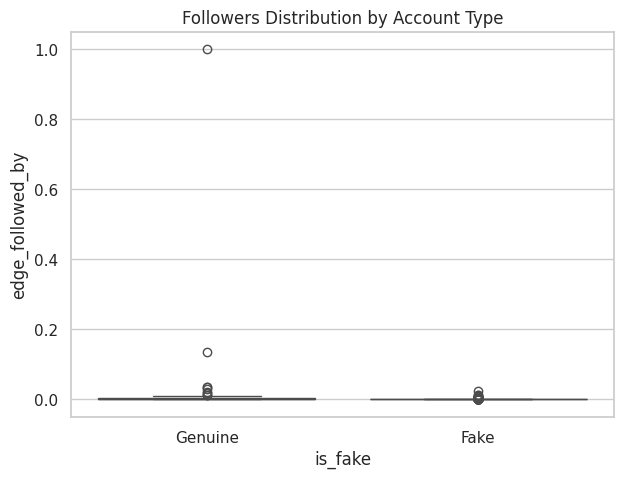

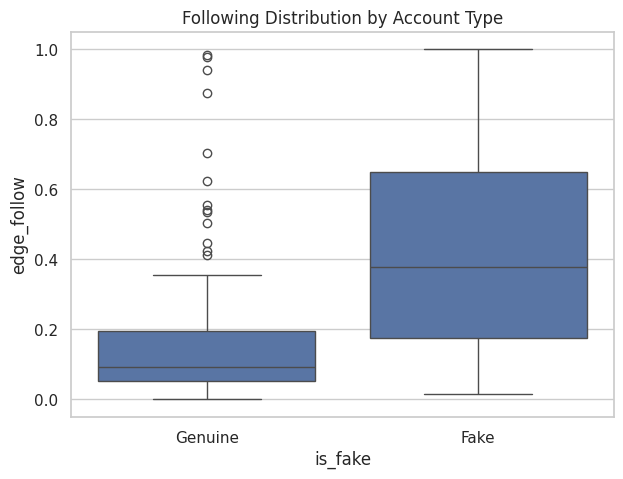

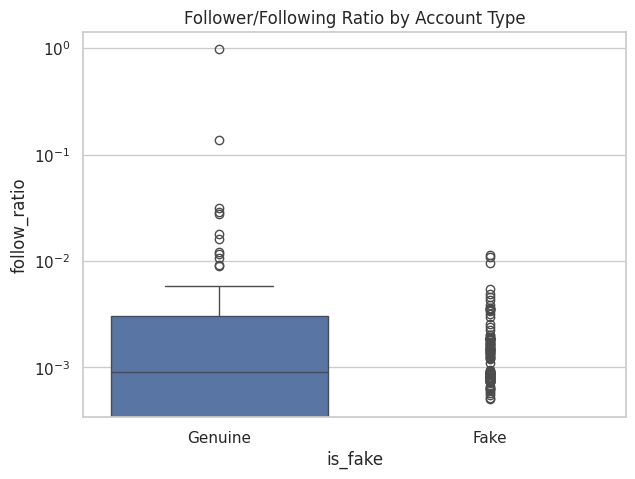

In [5]:
# Follower vs Following (edge_followed_by, edge_follow)
plt.figure(figsize=(7,5))
sns.boxplot(x='is_fake', y='edge_followed_by', data=df)
plt.title("Followers Distribution by Account Type")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x='is_fake', y='edge_follow', data=df)
plt.title("Following Distribution by Account Type")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

# Ratio
df['follow_ratio'] = df['edge_followed_by'] / (df['edge_follow'] + 1)

plt.figure(figsize=(7,5))
sns.boxplot(x='is_fake', y='follow_ratio', data=df)
plt.title("Follower/Following Ratio by Account Type")
plt.yscale("log")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

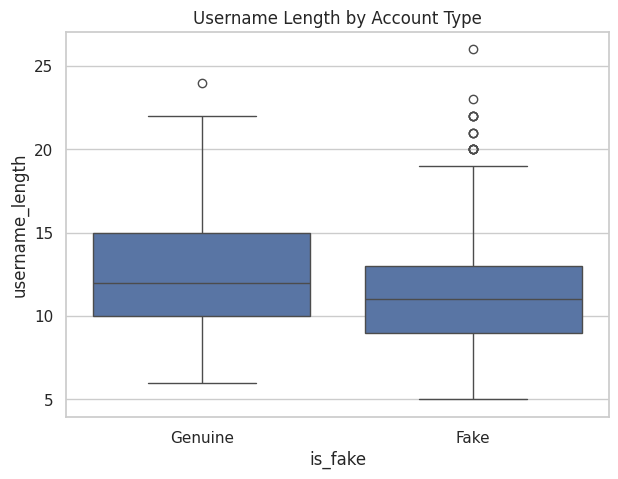

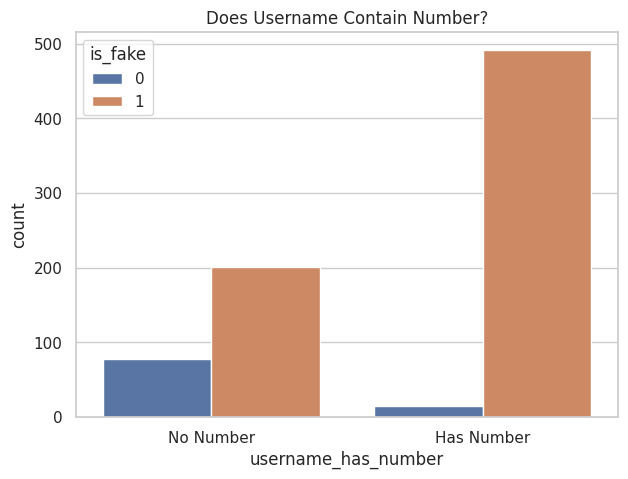

In [6]:
# Username Analysis
plt.figure(figsize=(7,5))
sns.boxplot(x='is_fake', y='username_length', data=df)
plt.title("Username Length by Account Type")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x='username_has_number', hue='is_fake', data=df)
plt.title("Does Username Contain Number?")
plt.xticks([0,1], ["No Number", "Has Number"])
plt.show()

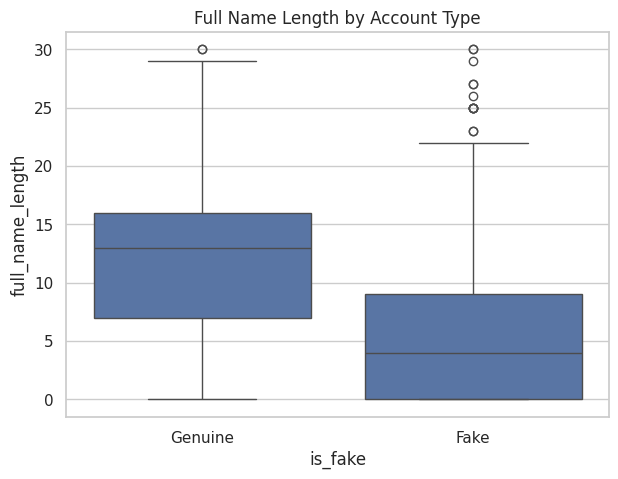

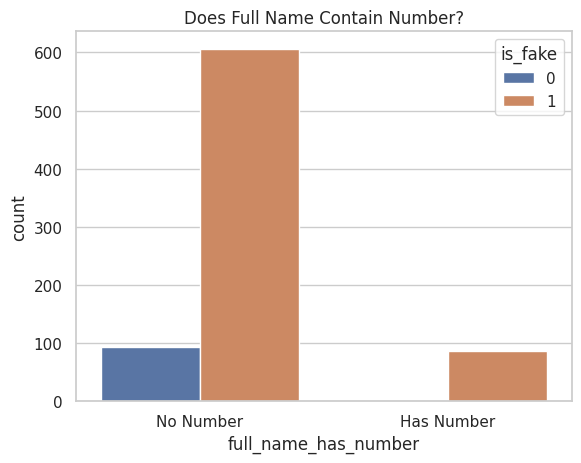

In [7]:
# Full Name Analysis
plt.figure(figsize=(7,5))
sns.boxplot(x='is_fake', y='full_name_length', data=df)
plt.title("Full Name Length by Account Type")
plt.xticks([0,1], ["Genuine", "Fake"])
plt.show()

sns.countplot(x='full_name_has_number', hue='is_fake', data=df)
plt.title("Does Full Name Contain Number?")
plt.xticks([0,1], ["No Number", "Has Number"])
plt.show()

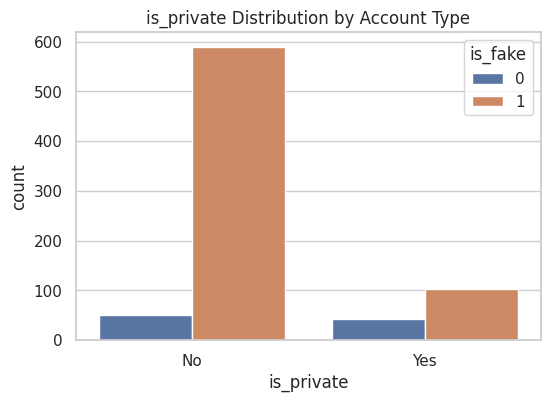

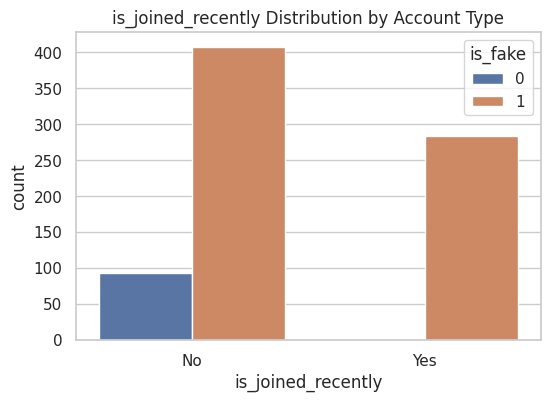

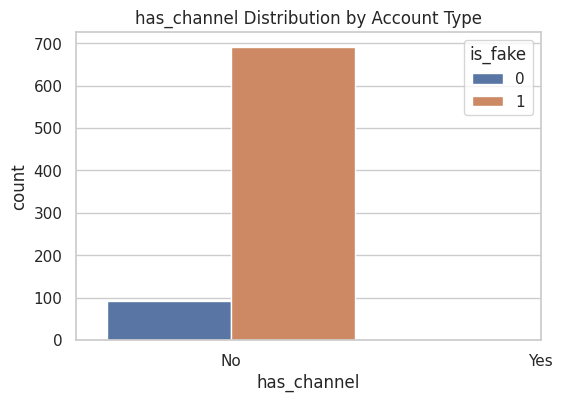

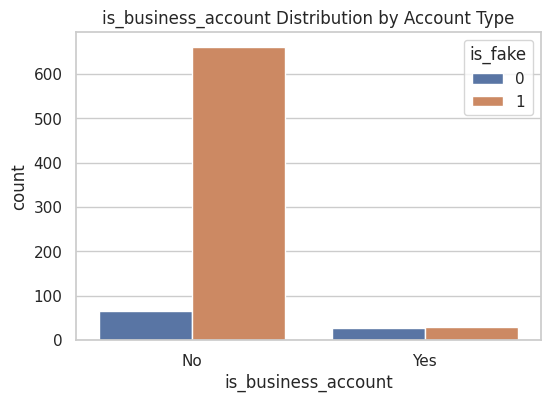

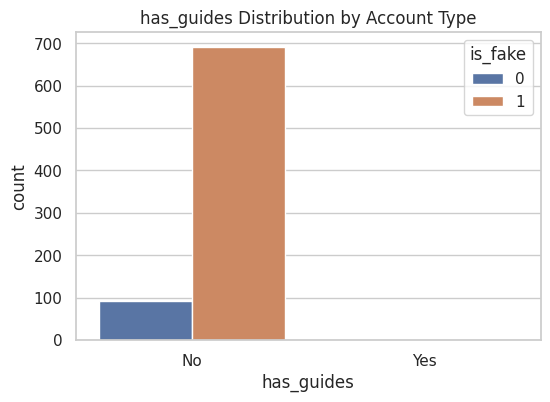

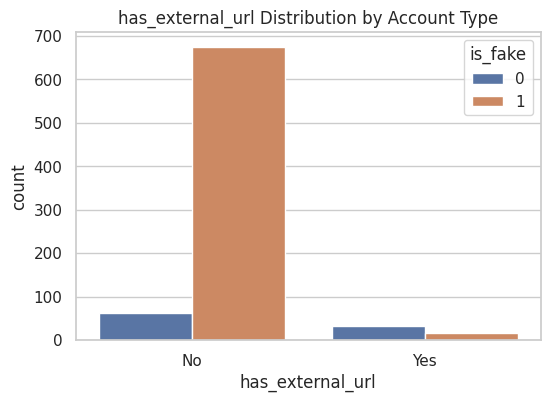

In [8]:
# Account Privacy & Features
binary_cols = [
    "is_private", "is_joined_recently", "has_channel",
    "is_business_account", "has_guides", "has_external_url"
]

for col in binary_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='is_fake', data=df)
    plt.title(f"{col} Distribution by Account Type")
    plt.xticks([0,1], ["No", "Yes"])
    plt.show()

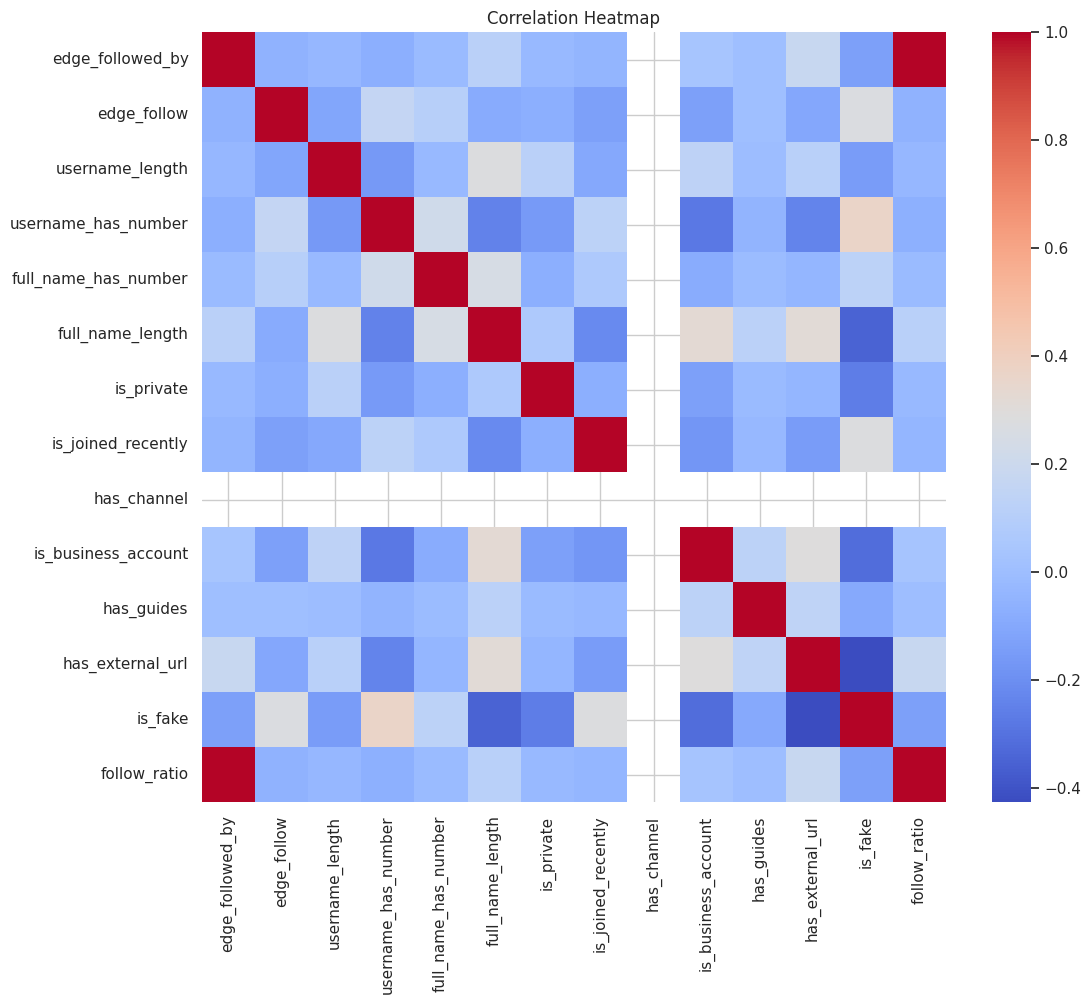

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()